# Text Preproscessing 

# Import  Eseention liberis

In [49]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud 
from sklearn.model_selection import train_test_split
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords


# Load the Clean data

In [50]:
data = pd.read_csv('../Data/cleaned_data.csv',encoding='latin-1')
data.head()

,target,messages,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [51]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


In [52]:
def text_preproceser(text):
    # 1. lowercase
    text = text.lower()
    
    # 2. tokenization
    words = nltk.word_tokenize(text)
    
    # 3. keep only alphanumeric
    words = [word for word in words if word.isalnum()]
    
    # 4. remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # 5. lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

In [53]:
# get a text
data['messages'][8]

'WINNER!! As a valued network customer you have been selected to receivea Ã¥Â£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.'

In [54]:
# chek 
test = 'WINNER!! As a valued network customer you have been selected to receivea Ã¥Â£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.'

# apply
text_preproceser(test)

'winner valued network customer selected receivea prize reward claim call claim code kl341 valid 12 hour'

# Apply text_preproceser on 'messages' Feature

In [55]:
# apply
data['process_text']=data['messages'].apply(text_preproceser)

# check
data.head()

,target,messages,num_characters,process_text
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think go usf life around though


In [56]:

wc = WordCloud(width=660,height=500,min_font_size=10,background_color='black')


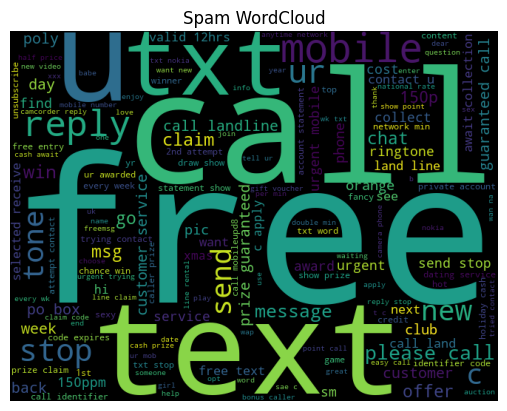

In [57]:
# most frequent words are in samp 
spam_wc = wc.generate(
    data[data['target']==1]['process_text'].str.cat(sep=" ")
)
# display
plt.imshow(spam_wc)
plt.axis('off')
plt.title("Spam WordCloud")
plt.show()

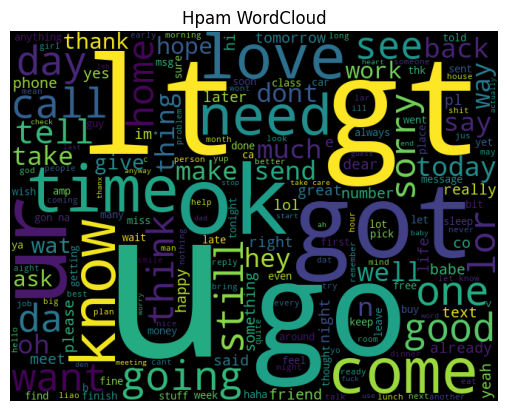

In [58]:
# most frequent words are in hamp 
spam_wc = wc.generate(
    data[data['target']==0]['process_text'].str.cat(sep=" ")
)
# display
plt.imshow(spam_wc)
plt.axis('off')
plt.title("Hpam WordCloud")
plt.show()

In [59]:
spam_corpus = []
for msg in data[data['target']==1]['process_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
# check its length
len(spam_corpus)

9936

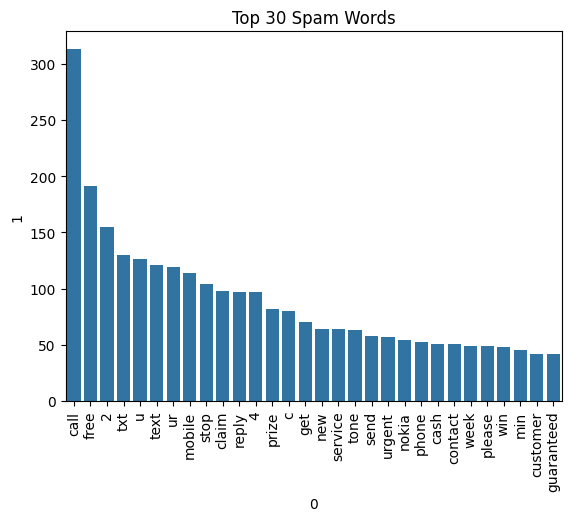

In [60]:
import seaborn as sns
from collections import Counter
# get top 30 words
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

# plot
sns.barplot(x=top_words[0], y=top_words[1])

plt.xticks(rotation='vertical')
plt.title("Top 30 Spam Words")
plt.show()

In [61]:
#hamp
hpam_corpus = []
for msg in data[data['target']==0]['process_text'].tolist():
    for word in msg.split():
        hpam_corpus.append(word)
# check its length
len(hpam_corpus)

35305

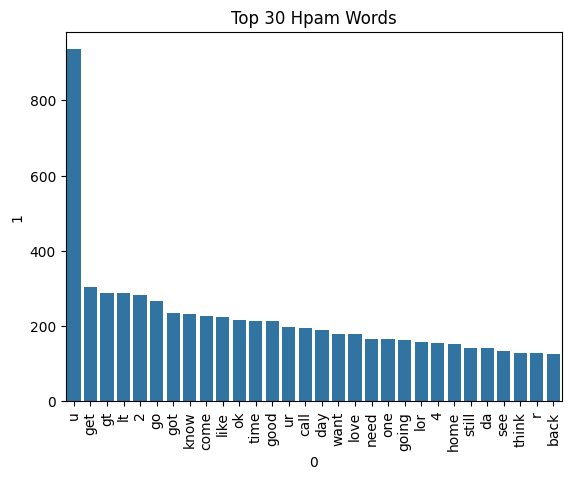

In [62]:
from collections import Counter
# get top 30 words
top_words = pd.DataFrame(Counter(hpam_corpus).most_common(30))

# plot
sns.barplot(x=top_words[0], y=top_words[1])

plt.xticks(rotation='vertical')
plt.title("Top 30 Hpam Words")
plt.show()

# Save preprocess data

In [63]:
data.head()

,target,messages,num_characters,process_text
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think go usf life around though


In [ ]:
df = data.copy()


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5169 entries, 0 to 5168
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   target          5169 non-null   int64
 1   messages        5169 non-null   str  
 2   num_characters  5169 non-null   int64
 3   process_text    5169 non-null   str  
dtypes: int64(2), str(2)
memory usage: 161.7 KB


In [66]:
data.columns

Index(['target', 'messages', 'num_characters', 'process_text'], dtype='str')

In [67]:
data = data[['process_text','target']]

data.to_csv('../Data/process_data.csv', index=False)
